In [ ]:
from pathlib import Path

import duckdb

## atc3_sick 기준 max로 하니 40조 -> 20조로 줄어듦 : 성공!

parquet_root = Path('/workspaces/healthcareDA/parquet')
temp_root = parquet_root / '.duckdb_tmp'
temp_root.mkdir(exist_ok=True)

target_folders = {  'atc3_sick', 'atc4_sick'} #'atc3_hosp', 'atc4_hosp'} #,
parquet_files = sorted(
    path for path in parquet_root.rglob('*.parquet')
    if path.parent.name in target_folders and not path.name.startswith('new_')
)

if not parquet_files:
    print(f'No parquet files found under {parquet_root}')

connection = duckdb.connect()
connection.execute("SET memory_limit = '512MB'")
connection.execute("SET threads = 1")
connection.execute("SET preserve_insertion_order = false")
connection.execute(f"SET temp_directory = '{temp_root.as_posix()}'")

try:
    for parquet_path in parquet_files:
        folder_name = parquet_path.parent.name
        output_path = parquet_path.with_name(f'new_{parquet_path.name}')
        if output_path.exists():
            output_path.unlink()

        source_sql = parquet_path.as_posix().replace("'", "''")
        output_sql = output_path.as_posix().replace("'", "''")
        schema = connection.execute(
            f"DESCRIBE SELECT * FROM read_parquet('{source_sql}')"
        ).fetchall()
        columns = [row[0] for row in schema]
        types = {row[0]: row[1] for row in schema}

        if folder_name in {'atc3_hosp', 'atc4_hosp'}:
            qty_col, amt_col = 'col_8', 'col_9'
        elif folder_name == 'atc4_sick':
            qty_col, amt_col = 'col_5', 'col_6'
        else:
            qty_col, amt_col = 'totUseQty', 'msupUseAmt'

        required = {qty_col, amt_col}
        if not required <= set(columns):
            raise ValueError(
                f'{parquet_path}: missing measure columns {required - set(columns)}'
            )

        source_relation = f"read_parquet('{source_sql}')"
        if folder_name.endswith('_hosp') and {'col_3', 'col_7'} <= set(columns):
            source_relation = f"""
                (
                    SELECT
                        * EXCLUDE (col_7),
                        CASE
                            WHEN regexp_matches(CAST(col_3 AS VARCHAR), '^[0-9]{{6}}$')
                            THEN LEFT(CAST(col_3 AS VARCHAR), 2)
                            ELSE col_7
                        END AS col_7
                    FROM {source_relation}
                )
            """

        group_columns = [column for column in columns if column not in required]
        select_parts = [f'"{column}"' for column in group_columns]
        for measure_column in (qty_col, amt_col):
            if types[measure_column].upper().startswith('VARCHAR'):
                expression = f'TRY_CAST("{measure_column}" AS DOUBLE)'
            else:
                expression = f'"{measure_column}"'
            select_parts.append(
                f'MIN({expression}) AS "{measure_column}"'
            )

        select_sql = ',\n                        '.join(select_parts)
        group_sql = ', '.join(f'"{column}"' for column in group_columns)
        connection.execute(
            f"""
            COPY (
                SELECT
                    {select_sql}
                FROM {source_relation}
                GROUP BY {group_sql}
            ) TO '{output_sql}' (FORMAT PARQUET, COMPRESSION ZSTD)
            """
        )
        print(f'Aggregated duplicates: {parquet_path}')
        print(f'Saved: {output_path}')
finally:
    connection.close()


Aggregated duplicates: /workspaces/healthcareDA/parquet/atc3_sick/06_getAtcStp3SickList_2020.parquet
Saved: /workspaces/healthcareDA/parquet/atc3_sick/new_06_getAtcStp3SickList_2020.parquet


In [4]:
con.close()



In [ ]:
## SICK , REGION FACIL -> AMT DIFFERENCE

import duckdb
con = duckdb.connect('healthcare.duckdb')
try :
    nt = con.execute(f"""
                SELECT 
                    diagYm,
                 atcStep2Cd,
                 atcStep3Cd,
                 regionStep2Cd,
                
                 insupTpCd,
                    medInstType,
                 totUseQty,
                 msupUseAmt,
                   count(*)
                
                FROM atc3_region_facil 
                WHERE insupTpCd IN ('4', '5', '7')
                GROUP BY 1,2,3,4,5,6,7,8
                having count(*) > 1
               ORDER BY 1,2,3,4,5,6,7,8

            """).df()
        
    display(nt)
except Exception as e:
    print(f"Error occurred: {e}") 

,diagYm,atcStep2Cd,atcStep3Cd,regionStep2Cd,insupTpCd,medInstType,totUseQty,msupUseAmt


In [10]:
import duckdb
connection = duckdb.connect('healthcare.duckdb')
connection.execute("""

CREATE or replace TABLE diag_region_atc3 AS
SELECT
    CAST(diagYm AS VARCHAR) AS diagYm,
    atcStep3Cd,
    insupTpCd,
    SUM(msupUseAmt) AS region_amt,
    SUM(totUseQty) AS region_qty,
    COUNT(*) AS region_rows
FROM atc3_region_facil
GROUP BY
    CAST(diagYm AS VARCHAR),
    atcStep3Cd,
    insupTpCd
    ;


CREATE or replace TABLE diag_sick_atc3 AS
SELECT
    CAST(diagYm AS VARCHAR) AS diagYm,
    atcStep3Cd,
    insupTpCd,
    SUM(msupUseAmt) AS sick_amt,
    SUM(totUseQty) AS sick_qty,
    COUNT(*) AS sick_rows
FROM atc3_sick
GROUP BY
    CAST(diagYm AS VARCHAR),
    atcStep3Cd,
    insupTpCd
    ;

CREATE or replace TABLE diag_atc3_compare AS
SELECT
    COALESCE(r.diagYm, s.diagYm) AS diagYm,
    COALESCE(r.atcStep3Cd, s.atcStep3Cd) AS atcStep3Cd,
    COALESCE(r.insupTpCd, s.insupTpCd) AS insupTpCd,

    COALESCE(r.region_amt, 0) AS region_amt,
    COALESCE(s.sick_amt, 0) AS sick_amt,

    COALESCE(r.region_amt, 0)
        - COALESCE(s.sick_amt, 0) AS diff_amt,

    COALESCE(r.region_qty, 0) AS region_qty,
    COALESCE(s.sick_qty, 0) AS sick_qty,

    COALESCE(r.region_rows, 0) AS region_rows,
    COALESCE(s.sick_rows, 0) AS sick_rows,

    CASE
        WHEN r.atcStep3Cd IS NULL THEN 'SICK_ONLY'
        WHEN s.atcStep3Cd IS NULL THEN 'REGION_ONLY'
        ELSE 'BOTH'
    END AS coverage_status

FROM diag_region_atc3 r
FULL OUTER JOIN diag_sick_atc3 s
    ON r.diagYm = s.diagYm
   AND r.atcStep3Cd = s.atcStep3Cd
   AND r.insupTpCd = s.insupTpCd
   ;

SELECT 
    left(diagYm, 4) AS diag_year,
    SUM(region_amt) / 1e12 AS region_trillion,
    SUM(sick_amt) / 1e12 AS sick_trillion,
    SUM(diff_amt) / 1e12 AS diff_trillion
FROM diag_atc3_compare
group by 1
order by 1
;
""").df().head(10)

,diag_year,region_trillion,sick_trillion,diff_trillion
0,2020,41.857825,36.048158,5.809668
1,2021,44.742265,38.959311,5.782954
2,2022,45.290984,39.576930,5.714054


In [12]:
connection.execute("""SELECT
    coverage_status,
    left(diagYm, 4) AS diag_year,
    COUNT(*) AS groups,
    SUM(region_amt) / 1e12 AS region_trillion,
    SUM(sick_amt) / 1e12 AS sick_trillion,
    SUM(diff_amt) / 1e12 AS diff_trillion
FROM diag_atc3_compare
GROUP BY coverage_status,2
ORDER BY ABS(diff_trillion) DESC;""").df()

,coverage_status,diag_year,groups,region_trillion,sick_trillion,diff_trillion
0,BOTH,2020,5626,4.185782e+01,36.048158,5.809667e+00
1,BOTH,2021,5601,4.474226e+01,38.959311,5.782954e+00
2,BOTH,2022,5593,4.529098e+01,39.576930,5.714053e+00
3,REGION_ONLY,2020,24,7.284780e-07,0.000000,7.284780e-07
4,REGION_ONLY,2021,13,6.061570e-07,0.000000,6.061570e-07
5,REGION_ONLY,2022,12,3.342710e-07,0.000000,3.342710e-07


In [13]:
connection.execute("""show tables ;""").df()

,name
0,atc3_region_facil
1,atc3_sick
2,atc4_region_facil
3,atc4_sick
4,atc_master
5,diag_atc3_compare
6,diag_region_atc3
7,diag_sick_atc3
8,region_facil_stat


In [14]:
connection.execute("""select * from diag_atc3_compare limit 1 ;""").df()

,diagYm,atcStep3Cd,insupTpCd,region_amt,sick_amt,diff_amt,region_qty,sick_qty,region_rows,sick_rows,coverage_status
0,202002,S02A,4,193547853.0,146373539.0,47174314.0,81586.0,62526.0,1097,715,BOTH


<Axes: title={'center': 'Total Use Amount (Region vs Sick) @ATC3'}, xlabel='Diagnosis Year-Month', ylabel='Amount (Trillion)'>

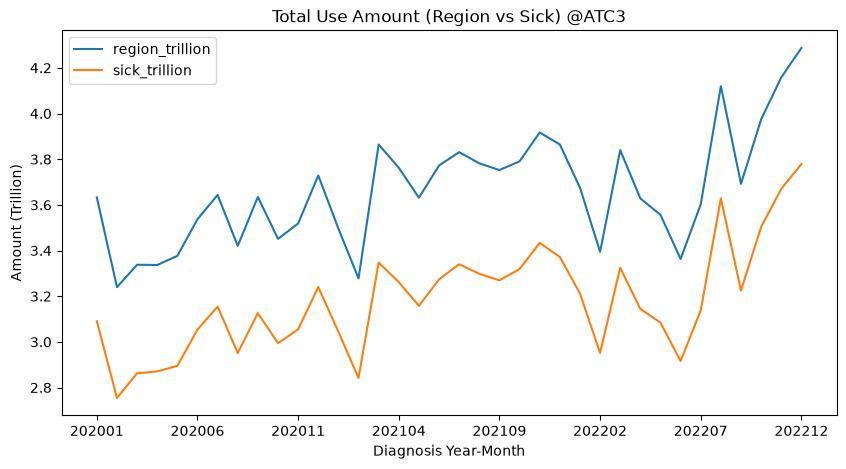

In [29]:
connection.execute("""select diagYm, sum(region_amt)/1e12 as region_trillion, sum(sick_amt)/1e12 as sick_trillion from diag_atc3_compare
group by 1 order by 1;""").df().plot(x='diagYm', y=['region_trillion', 'sick_trillion'], title='Total Use Amount (Region vs Sick) @ATC3', ylabel='Amount (Trillion)', xlabel='Diagnosis Year-Month', figsize=(10, 5))

<Axes: title={'center': 'Total Use Amount (ATC3 vs ATC4)(Trillion)'}, xlabel='Diagnosis Year-Month', ylabel='Amount (Trillion)'>

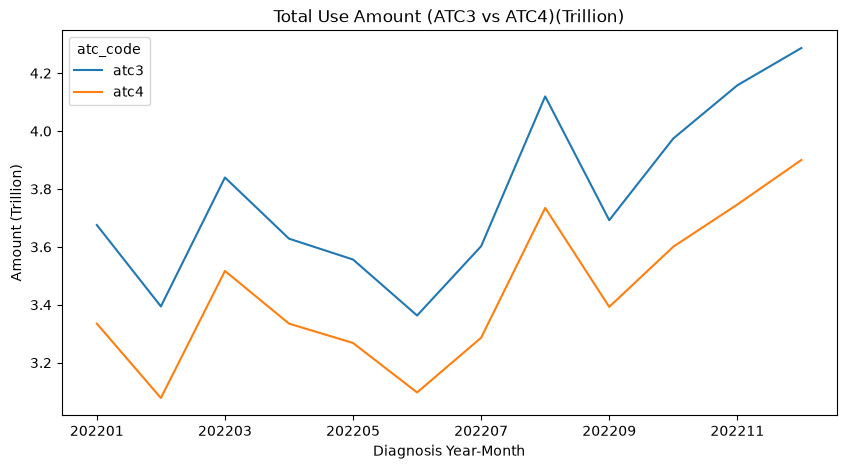

In [24]:
connection.execute("""
select diagYm, 'atc3' as atc_code, sum(msupUseAmt)/1e12 as atc_trillion    
from atc3_region_facil 
where diagYm >= '202201'
group by 1,2
union all
select diagYm, 'atc4' as atc_code, sum(msupUseAmt)/1e12 as atc_trillion
from atc4_region_facil
where diagYm >= '202201'    
group by 1,2
order by 2,1
;
""").df().pivot(index='diagYm', columns='atc_code', values='atc_trillion').fillna(0).plot(title='Total Use Amount (ATC3 vs ATC4)(Trillion)', ylabel='Amount (Trillion)', xlabel='Diagnosis Year-Month', figsize=(10, 5) )

In [2]:
import duckdb

connection = duckdb.connect('healthcare.duckdb')


for view_name in ['atc3_region_facil', 'atc4_region_facil', 'atc3_sick', 'atc4_sick']:
    idf = connection.execute(f"""
    SELECT COLUMN_NAME 
    FROM INFORMATION_SCHEMA.COLUMNS 
    WHERE TABLE_NAME = '{view_name}';
    ;
    """).df()
    display(idf.T)

,0,1,2,3,4,5,6,7,8,9,10,11
column_name,diagYm,atcStep2Cd,atcStep3Cd,regionStep2Cd,regionStep1CdNm,regionStep2CdNm,insupTpCd,regionStep1Cd,totUseQty,msupUseAmt,medInstType,atcStep3CdNm


,0,1,2,3,4,5,6,7,8,9,10,11
column_name,diagYm,atcStep3Cd,atcStep4Cd,regionStep2Cd,regionStep1CdNm,regionStep2CdNm,insupTpCd,regionStep1Cd,totUseQty,msupUseAmt,medInstType,atcStep4CdNm


,0,1,2,3,4,5,6,7
column_name,atcStep3Cd,atcStep3CdNm,diagYm,insupTpCd,st3SickSym,st3SickSymNm,totUseQty,msupUseAmt


,0,1,2,3,4,5,6,7
column_name,diagYm,st3SickSymNm,atcStep4Cd,insupTpCd,totUseQty,msupUseAmt,st3SickSym,atcStep4CdNm


In [3]:
import duckdb

connection = duckdb.connect("healthcare.duckdb")
for view_name in ['atc3_region_facil']: #, 'atc4_region_facil']:
    idf = connection.execute(f"""
    SELECT diagYm,	atcStep2Cd,	atcStep3Cd,	regionStep2Cd,	regionStep1CdNm,	regionStep2CdNm,
        	insupTpCd,	regionStep1Cd,	medInstType,	atcStep3CdNm, 
            COUNT(*)
            -- sum(msupUseAmt) as total_amt, sum(totUseQty) as total_qty
    FROM {view_name}
    where diagym like '20211%'
    GROUP BY diagYm,	atcStep2Cd,	atcStep3Cd,	regionStep2Cd,	regionStep1CdNm,	regionStep2CdNm,
        	insupTpCd,	regionStep1Cd,	medInstType,	atcStep3CdNm
    HAVING COUNT(*) > 1
    order by diagYm, atcStep2Cd, atcStep3Cd, regionStep2Cd, regionStep1CdNm, regionStep2CdNm,
        	insupTpCd, regionStep1Cd, medInstType, atcStep3CdNm
    ;
    """).df()
    display(idf)

,diagYm,atcStep2Cd,atcStep3Cd,regionStep2Cd,regionStep1CdNm,regionStep2CdNm,insupTpCd,regionStep1Cd,medInstType,atcStep3CdNm,count_star()
0,202110,A02,A02A,110001,서울,강남구,4,11,병원,ANTACIDS,2
1,202110,A02,A02A,110001,서울,강남구,4,11,상급종합병원,ANTACIDS,2
2,202110,A02,A02A,110001,서울,강남구,4,11,요양병원,ANTACIDS,2
3,202110,A02,A02A,110001,서울,강남구,4,11,의원,ANTACIDS,2
4,202110,A02,A02A,110001,서울,강남구,4,11,종합병원,ANTACIDS,2
...,...,...,...,...,...,...,...,...,...,...,...
391580,202112,V08,V08A,311000,경기,구리시,5,31,의원,"X-RAY CONTRAST MEDIA, IODINATED",2
391581,202112,V08,V08A,312300,경기,김포시,4,31,의원,"X-RAY CONTRAST MEDIA, IODINATED",2
391582,202112,V08,V08A,360012,전남,신안군,4,36,의원,"X-RAY CONTRAST MEDIA, IODINATED",2
391583,202112,V08,V08A,360300,전남,목포시,4,36,의원,"X-RAY CONTRAST MEDIA, IODINATED",2


In [3]:
connection.execute("""select * from atc3_region_facil 
where diagYm like '20211%' 
and atcStep3CdNm = 'ANTACIDS' and regionStep2Cd = '110001' and atcStep3Cd = 'A02A' and medInstType = '병원' and diagym = 202110
order by diagYm, atcStep2Cd, atcStep3Cd, regionStep2Cd, regionStep1CdNm, regionStep2CdNm, 
insupTpCd, regionStep1Cd, medInstType, atcStep3CdNm 
""").df()

,diagYm,atcStep2Cd,atcStep3Cd,regionStep2Cd,regionStep1CdNm,regionStep2CdNm,insupTpCd,regionStep1Cd,totUseQty,msupUseAmt,medInstType,atcStep3CdNm
0,202110,A02,A02A,110001,서울,강남구,4,11,64492.0,2008231.0,병원,ANTACIDS
1,202110,A02,A02A,110001,서울,강남구,5,11,3564.0,128461.0,병원,ANTACIDS
2,202110,A02,A02A,110001,서울,강남구,7,11,90.0,1620.0,병원,ANTACIDS


,atcStep3Cd,atcStep3CdNm,diagYm,insupTpCd,st3SickSym,st3SickSymNm,totUseQty,msupUseAmt
0,N02A,OPIOIDS,202110,4,AE10,1형 당뇨병,14723,5271618


In [10]:
import duckdb

connection = duckdb.connect("healthcare.duckdb")
for view_name in ['atc3_sick']: #, 'atc4_region_facil']:
    idf = connection.execute(f"""
    SELECT diagYm,	atcStep3Cd,	insupTpCd,	st3sicksym,
            COUNT(*)
            -- sum(msupUseAmt) as total_amt, sum(totUseQty) as total_qty
    FROM {view_name}
    where diagym like '20211%'
    GROUP BY 1,2,3,4
    HAVING COUNT(*) > 1
    order by 1,2,3,4
    ;
    """).df()
    display(idf)

,diagYm,atcStep3Cd,insupTpCd,st3SickSym,count_star()
0,202110,A02A,4,AA00,2
1,202110,A02A,4,AA01,2
2,202110,A02A,4,AA02,2
3,202110,A02A,4,AA04,2
4,202110,A02A,4,AA05,2
...,...,...,...,...,...
416257,202112,V08A,4,AS33,2
416258,202112,V08A,5,AG53,2
416259,202112,V08A,5,AI20,2
416260,202112,V08A,5,AM48,2


In [11]:
connection.execute("""select * from atc3_sick 
where diagYm like '20211%' 
AND atcStep3Cd = 'A02A' AND insupTpCd = '4' AND st3sicksym = 'AA00' AND DIAGYM = 202110
;
""").df()

,atcStep3Cd,atcStep3CdNm,diagYm,insupTpCd,st3SickSym,st3SickSymNm,totUseQty,msupUseAmt
0,A02A,ANTACIDS,202110,4,AA00,콜레라,2471,76402
1,A02A,ANTACIDS,202110,4,AA00,콜레라,14,770
